First 5 rows of the data:
         Date   Price    Open    High     Low  Volume  Chg%
0  2026-01-02  135793  136143  137037  135525   51877  0.02
1  2026-01-01  135771  135687  135850  135001   14622  0.23
2  2025-12-31  135454  136526  136527  134866   59050  1.10
3  2025-12-30  133974  133185  134880  132853   36733  1.04
4  2025-12-29  132595  137628  138269  131695   90640 -3.77

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   object 
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 169.9+ KB
None
Descriptive statistics:
                                Date          Price           O

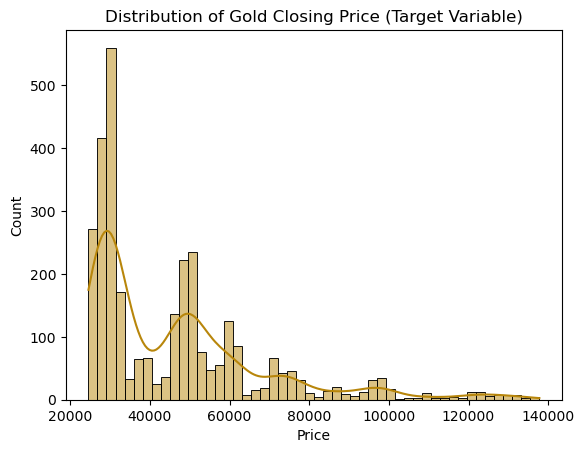

Skewness: 1.5941140470101642


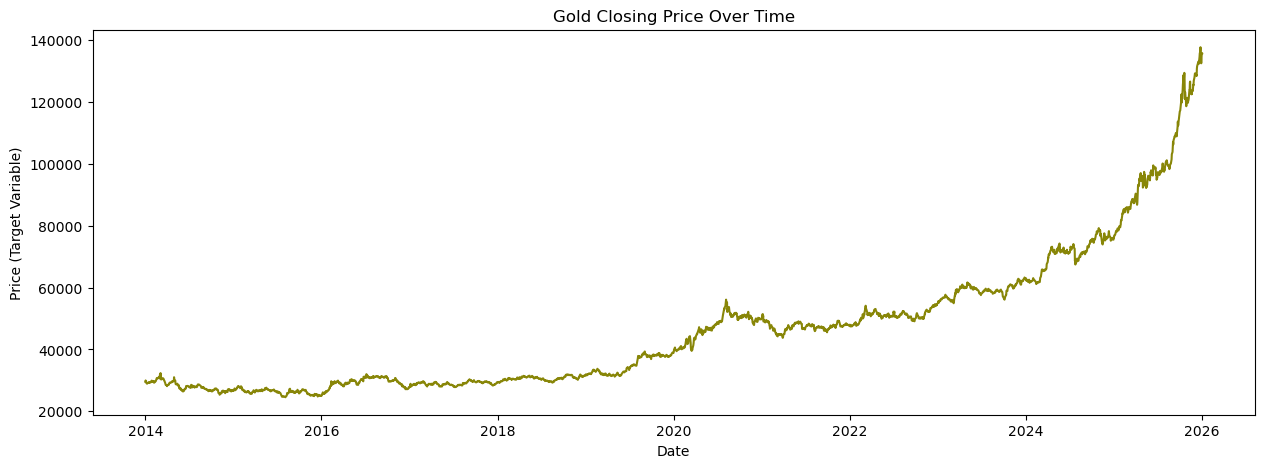

------------------------------------------------------------
DATA PREPARATION
------------------------------------------------------------

1. Checking for missing values:
Date      0
Price     0
Open      0
High      0
Low       0
Volume    0
Chg%      0
dtype: int64

2. Number of duplicate rows: 0

3. Extracting time-based features...
=== Added time-based features: Year, Month, Day, DayOfWeek, Quarter ===

4. Building return-based features...
=== Added Return_Today + Return_Lag_1,2,3,5,10 ===

5. Creating rolling ratio/volatility features...
=== Added MA_Ratio_3,5,10,20 and Vol_3,5,10,20 ===

6. Creating price-derived features...
=== Added Daily_Range_Pct, Price_Open_Ratio ===

7. Creating volume features...
=== Added Volume_Lag_1,3,5, Volume_MA_5,10, Volume_Ratio ===

8. Creating target variables...
=== Added Target (next-day price) and Target_Return (next-day return) ===

Feature count: 23
['Date', 'Price', 'Open', 'High', 'Low', 'Volume', 'Chg%', 'Year', 'Month', 'Day', 'DayOfWeek

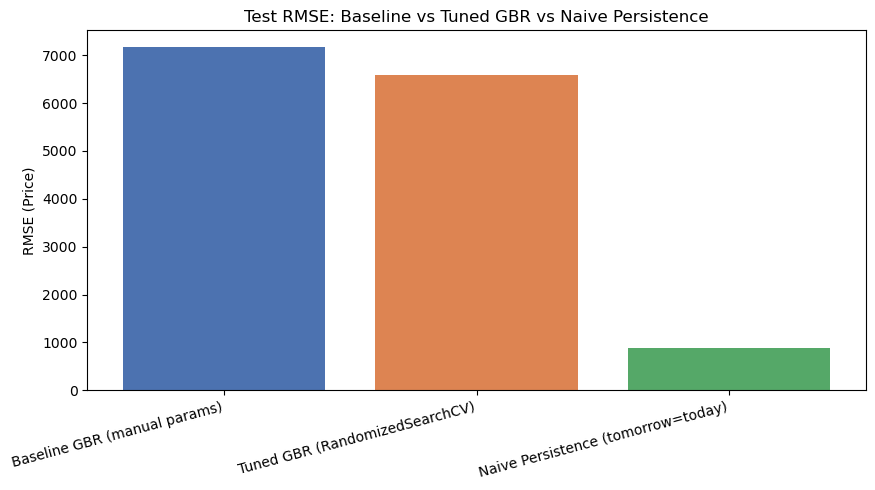


Top 10 Feature Importances
     Feature  Importance
Volume_MA_10    0.448545
      Vol_20    0.131131
Volume_Lag_1    0.089660
 Volume_MA_5    0.058535
Volume_Lag_3    0.056966
 MA_Ratio_20    0.052151
Volume_Lag_5    0.028913
      Vol_10    0.026444
Volume_Ratio    0.023248
 MA_Ratio_10    0.017650


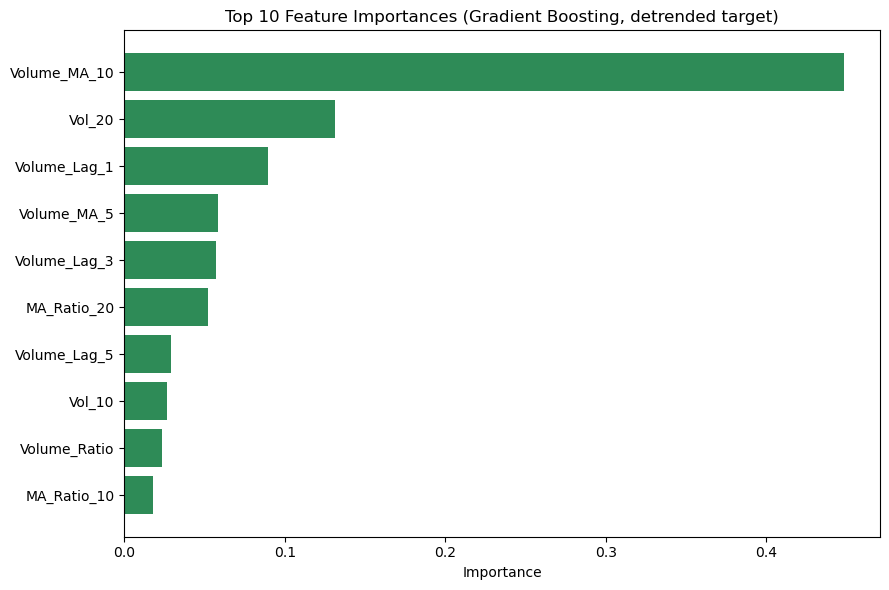

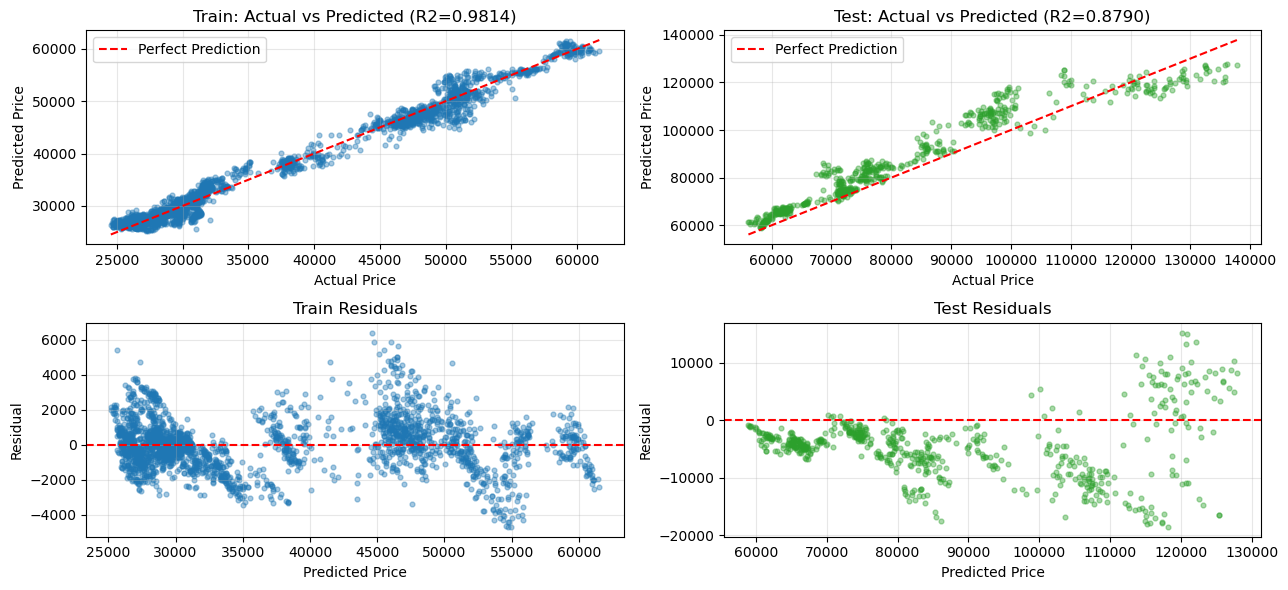

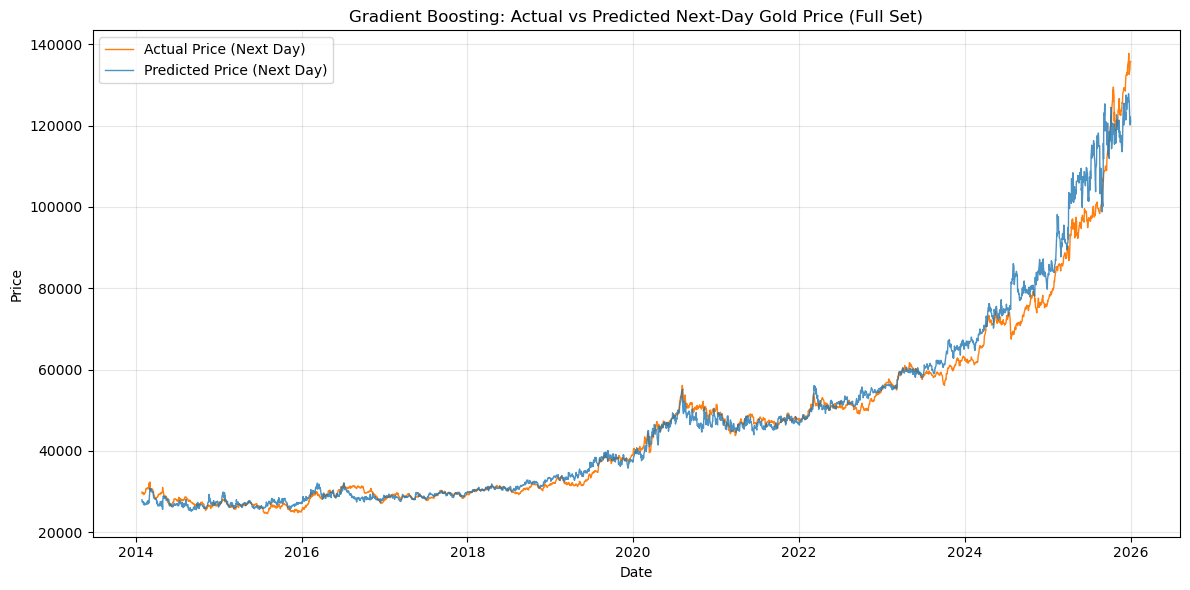

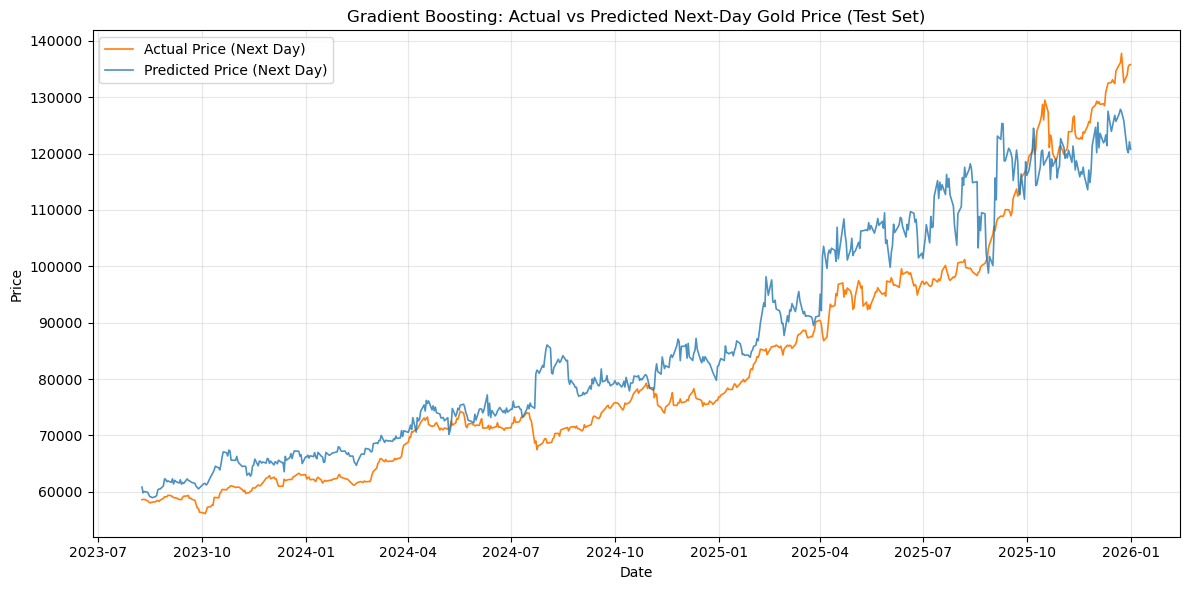


[37.8s] Model A done. Baseline Test R2=0.8790, Tuned Test R2=0.8979, Naive Persistence Test R2=0.9982

MODEL B: RETURN-BASED TARGET
[55.5s] Model B trained

------------------------------------------------------------
VECTORIZED MONTE CARLO FORECAST (GBR, 300 paths, with dampening)
------------------------------------------------------------
[55.7s] simulated day 50/252
[55.8s] simulated day 100/252
[56.0s] simulated day 150/252
[56.1s] simulated day 200/252
[56.3s] simulated day 250/252
        Date  Forecast_Path         Median       Lower_5%      Upper_95%
0 2026-01-02  134663.066876  136276.092063  134662.831227  138149.286018
1 2026-01-05  133110.882496  136288.205633  133464.470677  139415.042219
2 2026-01-06  135297.850486  136838.939614  133106.065667  140263.499289
3 2026-01-07  135415.346206  137295.897623  132559.974957  141452.946874
4 2026-01-08  135246.143475  137555.785207  132525.688311  141807.794642
          Date  Forecast_Path         Median       Lower_5%      Upp

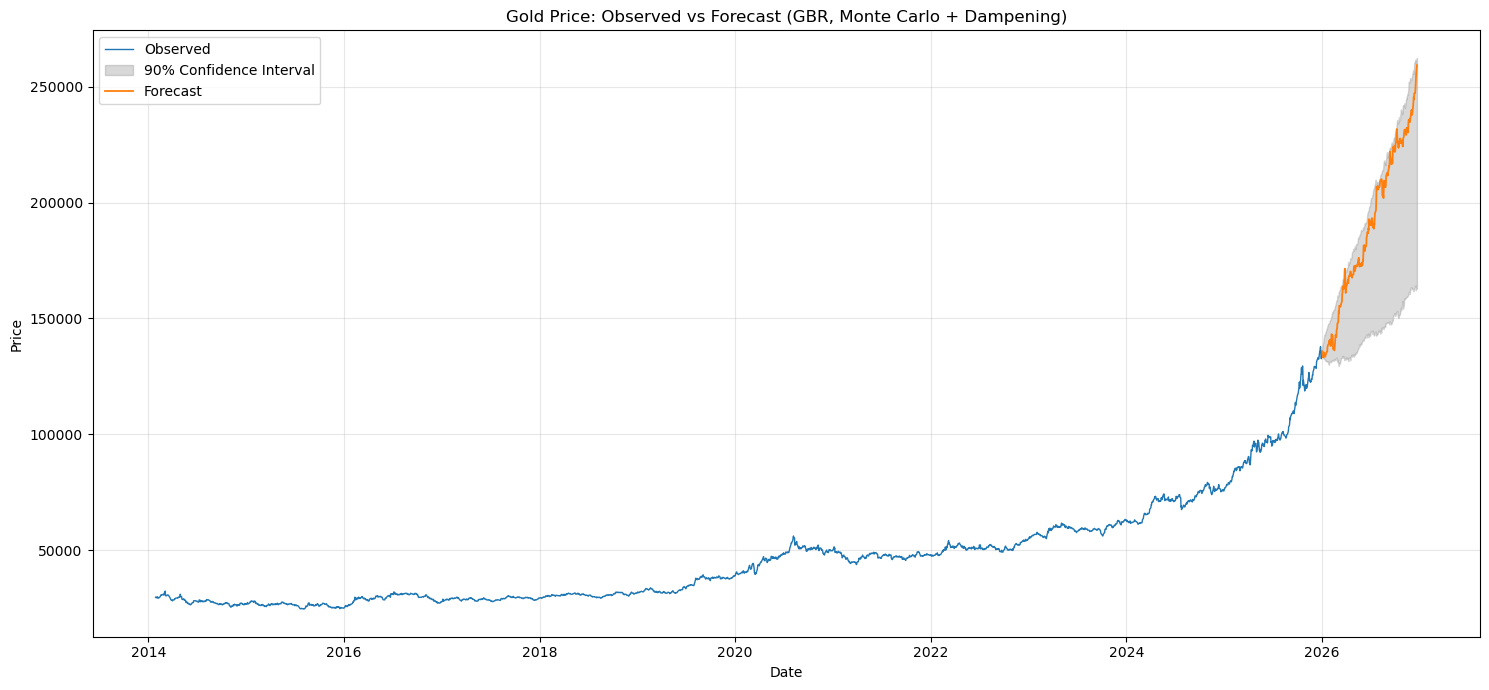

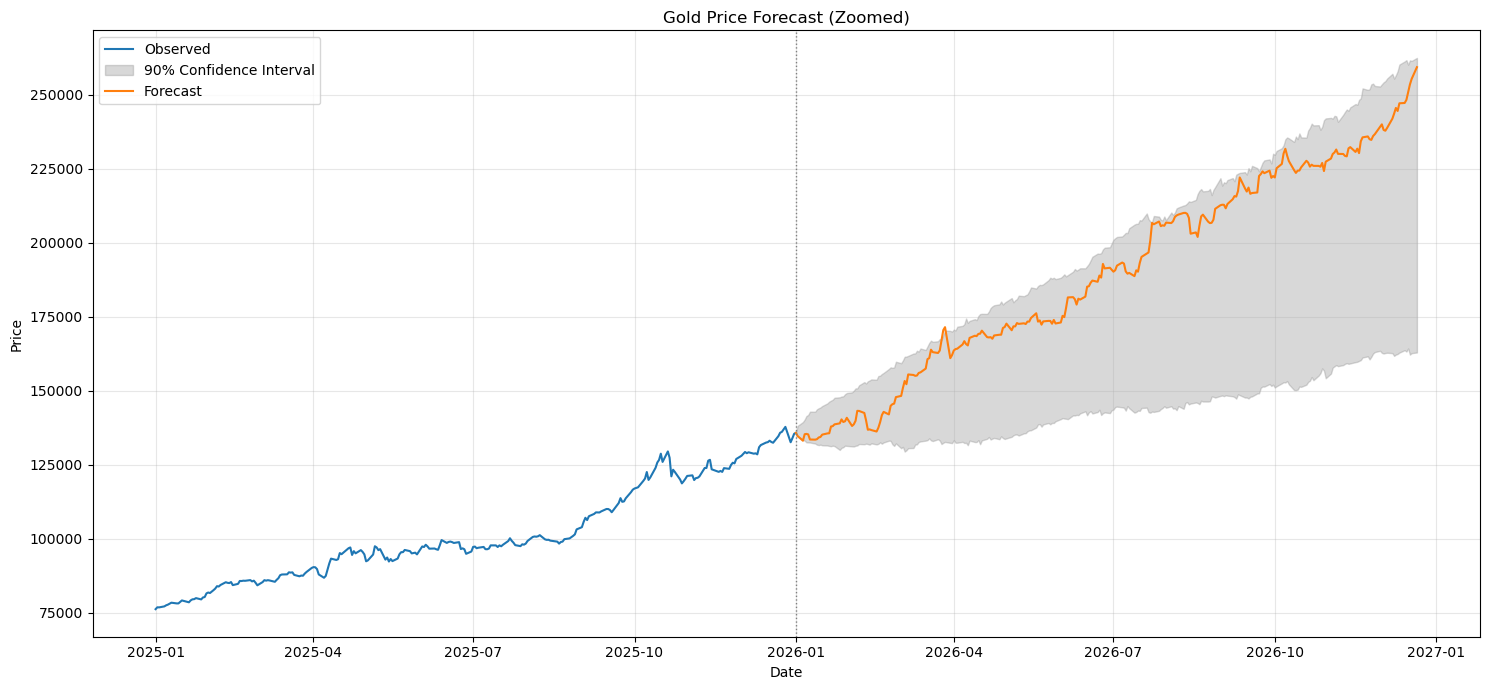


[57.7s] Done.
Model A -- Baseline Test R2: 0.8790 | Tuned Test R2: 0.8979 | Naive Test R2: 0.9982


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Gold Price.csv")
pd.set_option('display.max_columns', None)

#########
# View the first 5 rows of the data
print("First 5 rows of the data:")
print(df.head(5))

#########
# View basic information about the data
print("\nData information:")
print(df.info())

# Convert date format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (ensure correct chronological order)
df = df.sort_values('Date').reset_index(drop=True)

#########
# View descriptive statistics
print("Descriptive statistics:")
print(df.describe())

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

#########
print(f"Statistical Properties of Price:")
print(df['Price'].describe())

sns.histplot(df['Price'], kde=True, bins=50, color='#B8860B')
plt.title('Distribution of Gold Closing Price (Target Variable)')
plt.xlabel('Price')
plt.show()
print("Skewness:", df['Price'].skew())

plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Price'], color='#888608')
plt.title('Gold Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (Target Variable)')
plt.show()

# ============================================================
# DATA PREPARATION - Feature Engineering
# ============================================================
print("-" * 60)
print("DATA PREPARATION")
print("-" * 60)

# 1. Check for missing values (verification)
print("\n1. Checking for missing values:")
print(df.isnull().sum())

# 2. Check for duplicate values
print(f"\n2. Number of duplicate rows: {df.duplicated().sum()}")

# 3. Time-based features
# 🔧 Year/Month/Day/Quarter kept for EDA/reporting only -- NOT part
# of feature_cols (models use DayOfWeek only, same as before).
print("\n3. Extracting time-based features...")
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Quarter'] = df['Date'].dt.quarter
print("=== Added time-based features: Year, Month, Day, DayOfWeek, Quarter ===")

print("\n4. Building return-based features...")
df['Return'] = df['Price'].pct_change()


df['Return_Today'] = df['Return']

for lag in [1, 2, 3, 5, 10]:
    df[f'Return_Lag_{lag}'] = df['Return'].shift(lag)
print("=== Added Return_Today + Return_Lag_1,2,3,5,10 ===")

# 5. Rolling ratio/volatility features (replaces raw MA_/Std_)
print("\n5. Creating rolling ratio/volatility features...")
for window in [3, 5, 10, 20]:
    df[f'MA_{window}'] = df['Price'].rolling(window).mean()          # kept for transparency, not a model feature itself
    df[f'MA_Ratio_{window}'] = df['Price'] / df[f'MA_{window}'] - 1  # feature: % above/below the MA
    df[f'Vol_{window}'] = df['Return'].rolling(window).std()         # feature: rolling return volatility
print("=== Added MA_Ratio_3,5,10,20 and Vol_3,5,10,20 ===")

# 6. Price-derived features
print("\n6. Creating price-derived features...")
df['Daily_Range_Pct'] = (df['High'] - df['Low']) / df['Low'] * 100
#
df['Price_Open_Ratio'] = df['Price'] / df['Open'] - 1
print("=== Added Daily_Range_Pct, Price_Open_Ratio ===")

# 7. Volume features
print("\n7. Creating volume features...")
for lag in [1, 3, 5]:
    df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)
df['Volume_MA_5'] = df['Volume'].rolling(5).mean()
df['Volume_MA_10'] = df['Volume'].rolling(10).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_10']
print("=== Added Volume_Lag_1,3,5, Volume_MA_5,10, Volume_Ratio ===")

# 8. Targets

print("\n8. Creating target variables...")
df['Target'] = df['Price'].shift(-1)          # next-day price (Model A / evaluation target)
df['Target_Return'] = df['Return'].shift(-1)  # next-day return (Model B / forecast-engine target)
print("=== Added Target (next-day price) and Target_Return (next-day return) ===")


feature_cols = [
    'DayOfWeek',
    'Return_Today',
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10',
    'MA_Ratio_3', 'MA_Ratio_5', 'MA_Ratio_10', 'MA_Ratio_20',
    'Vol_3', 'Vol_5', 'Vol_10', 'Vol_20',
    'Daily_Range_Pct', 'Price_Open_Ratio',
    'Volume_Ratio', 'Volume_MA_5', 'Volume_MA_10',
    'Volume_Lag_1', 'Volume_Lag_3', 'Volume_Lag_5',
]
print(f"\nFeature count: {len(feature_cols)}")
print(df.columns.tolist())

# 10. Outlier detection (IQR on Daily_Range_Pct) -- flag, don't drop
lo = df["Daily_Range_Pct"].quantile(0.25)
hi = df["Daily_Range_Pct"].quantile(0.75)
inter = hi - lo
lbound = lo - (inter * 1.5)
hbound = hi + (inter * 1.5)

print("\n" + "-" * 60)
print("Outlier Detection (IQR method on Daily_Range_Pct)")
print("-" * 60)
print("Interquartile range of the daily range (%):", round(inter, 4))
print("Boundaries:", round(lbound, 4), ",", round(hbound, 4))

out = df[(df["Daily_Range_Pct"] > hbound) | (df["Daily_Range_Pct"] < lbound)]
print(f"Number of outliers detected: {len(out)} out of {len(df)} rows "
      f"({len(out) / len(df) * 100:.2f}%)")

out_by_year = out.copy()
out_by_year['Year'] = pd.to_datetime(out_by_year['Date']).dt.year
print("\nOutliers by year:")
print(out_by_year['Year'].value_counts().sort_index())

df['Is_Extreme_Day'] = ((df['Daily_Range_Pct'] > hbound) |
                         (df['Daily_Range_Pct'] < lbound)).astype(int)
print(f"\n'Is_Extreme_Day' flag added. "
      f"{df['Is_Extreme_Day'].sum()} rows flagged as extreme. "
      f"(informational only -- not in feature_cols)")

# 11. Drop rows with NaN feature values
print("\n" + "-" * 60)
print(f"Data size before dropping feature-NaN rows: {len(df)}")
df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Data size after dropping feature-NaN rows: {len(df_clean)}")
print(f"Dropped {len(df) - len(df_clean)} rows (startup rows from lag/rolling features)")
print(f"Rows with Target still NaN (expected: 1, the most recent day): "
      f"{df_clean['Target'].isna().sum()}")

# 12. Save the cleaned data -- SINGLE SOURCE OF TRUTH for all models
df_clean.to_csv('Gold_Price_Cleaned.csv', index=False)
print("\n=== Cleaned data saved as 'Gold_Price_Cleaned.csv' ===")

# 13. Final summary
print("\n" + "-" * 60)
print("Final Data Summary")
print("-" * 60)
print(f"Total records: {len(df_clean)}")
print(f"Number of features: {len(df_clean.columns)}")
print(f"Feature columns used by models: {len(feature_cols)}")
print(f"Date range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"\nStatistics for target variable 'Target' (rows where defined):")
print(f"  Mean: {df_clean['Target'].mean():.2f}")
print(f"  Standard deviation: {df_clean['Target'].std():.2f}")
print(f"  Minimum: {df_clean['Target'].min():.2f}")
print(f"  Maximum: {df_clean['Target'].max():.2f}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

np.random.seed(42)
t0 = time.time()


df = pd.read_csv("Gold_Price_Cleaned.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

feature_cols = [
    'DayOfWeek',
    'Return_Today',
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10',
    'MA_Ratio_3', 'MA_Ratio_5', 'MA_Ratio_10', 'MA_Ratio_20',
    'Vol_3', 'Vol_5', 'Vol_10', 'Vol_20',
    'Daily_Range_Pct', 'Price_Open_Ratio',
    'Volume_Ratio', 'Volume_MA_5', 'Volume_MA_10',
    'Volume_Lag_1', 'Volume_Lag_3', 'Volume_Lag_5',
]
print(f"Feature count: {len(feature_cols)}")


# ============================================================
# DETRENDED TARGET (evaluation)
# ============================================================

# 🔧 data_prep.py already dropped the startup rows where features
# themselves were NaN, so this only drops the trailing row(s) where
# Target ("tomorrow's price") isn't known yet -- typically 1 row.
df_clean_A = df.dropna(subset=feature_cols + ['Target']).reset_index(drop=True)
df_clean_A['TimeIndex'] = np.arange(len(df_clean_A))

X_A = df_clean_A[feature_cols]
y_A = df_clean_A['Target']

# ============================================================
# TRAIN / TEST SPLIT (time-ordered) -- for honest evaluation
# ============================================================

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y_A,
    test_size=0.2,
    shuffle=False
)

idx_train_A, idx_test_A = train_test_split(
    df_clean_A['TimeIndex'],
    test_size=0.2,
    shuffle=False
)

print("=" * 60)
print("TRAIN / TEST SHAPES")
print("=" * 60)
print(f"X_train shape: {X_train_A.shape}")
print(f"X_test  shape: {X_test_A.shape}")


print("\n" + "=" * 60)
print("GBR EVALUATION -- BASELINE (Target = Next-Day Price, log-detrended)")
print("=" * 60)

#log trend
log_price_train = np.log(y_train_A.values)
t_train = idx_train_A.values.reshape(-1, 1)
t_test = idx_test_A.values.reshape(-1, 1)

trend_lin = LinearRegression().fit(t_train, log_price_train)
trend_quad = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(t_train, log_price_train)
r2_lin = r2_score(log_price_train, trend_lin.predict(t_train))
r2_quad = r2_score(log_price_train, trend_quad.predict(t_train))
use_quad = r2_quad > r2_lin
trend_model = trend_quad if use_quad else trend_lin
print(f"Trend: {'quadratic' if use_quad else 'linear'} "
      f"(linear R2={r2_lin:.4f}, quadratic R2={r2_quad:.4f})")

log_trend_train = trend_model.predict(t_train)
log_trend_test = trend_model.predict(t_test)
target_detrended_train = log_price_train - log_trend_train
target_detrended_test = np.log(y_test_A.values) - log_trend_test

#  ============================================================
eval_gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)
eval_gbr.fit(X_train_A, target_detrended_train)
 
pred_detrended_train = eval_gbr.predict(X_train_A)
pred_detrended_test = eval_gbr.predict(X_test_A)
pred_price_train = np.exp(pred_detrended_train + log_trend_train)
pred_price_test = np.exp(pred_detrended_test + log_trend_test)
 
def metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:20s} | MSE: {mse:14.2f} | RMSE: {rmse:10.2f} | MAE: {mae:10.2f} | R2: {r2:.4f}")
    return mse, rmse, mae, r2
 
print()
trainA_mse, trainA_rmse, trainA_mae, trainA_r2 = metrics(y_train_A, pred_price_train, "BASELINE-TRAIN")
testA_mse, testA_rmse, testA_mae, testA_r2 = metrics(y_test_A, pred_price_test, "BASELINE-TEST")
naive_trend_only_r2 = r2_score(y_test_A, np.exp(log_trend_test))
print(f"{'NAIVE(trend)':20s} | R2 (test): {naive_trend_only_r2:.4f}   <-- trend alone, no GBR residual")
print(f"Train/Test R2 gap: {trainA_r2 - testA_r2:.4f}")
 
# ============================================================
# NAIVE PERSISTENCE BASELINE (predict tomorrow = today's closing price)
# ============================================================
print("\n" + "=" * 60)
print(" NAIVE PERSISTENCE BASELINE (predict tomorrow = today's closing price)")
print("=" * 60)
 
naive_pred_train_A = df_clean_A.loc[X_train_A.index, 'Price'].values
naive_pred_test_A = df_clean_A.loc[X_test_A.index, 'Price'].values
naive_mse_tr_A, naive_rmse_tr_A, naive_mae_tr_A, naive_r2_tr_A = metrics(y_train_A, naive_pred_train_A, "NAIVE-TRAIN")
naive_mse_te_A, naive_rmse_te_A, naive_mae_te_A, naive_r2_te_A = metrics(y_test_A, naive_pred_test_A, "NAIVE-TEST")
 
# ============================================================
# 4B. 5-FOLD TIME SERIES CROSS-VALIDATION (BASELINE HYPERPARAMS)
# ============================================================
print("\n" + "=" * 60)
print("5-FOLD TIME SERIES CROSS-VALIDATION (Baseline hyperparameters)")
print("=" * 60)
 
tscv = TimeSeriesSplit(n_splits=5)
cv_results = cross_validate(
    GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        min_samples_split=10, min_samples_leaf=5, subsample=0.8,
        random_state=42
    ),
    X_train_A, target_detrended_train,
    cv=tscv,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
    return_train_score=False,
)
cv_r2 = cv_results["test_r2"]
cv_rmse = -cv_results["test_rmse"]
print(f"Mean R2 (detrended scale):   {cv_r2.mean():.4f}  (std {cv_r2.std():.4f})")
print(f"Mean RMSE (detrended scale): {cv_rmse.mean():.4f}  (std {cv_rmse.std():.4f})")
 
cv_df_A = pd.DataFrame({"fold": range(1, 6), "r2": cv_r2, "rmse_detrended": cv_rmse})
cv_df_A.to_csv("gold_gbr_5fold_cv_results.csv", index=False)
print(cv_df_A.to_string(index=False))
 
# ============================================================
# 4C. HYPERPARAMETER TUNING (RandomizedSearchCV)
# ============================================================
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING (RandomizedSearchCV, 3-fold TimeSeriesSplit)")
print("=" * 60)
 
param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [5, 10, 20, 50],
    "min_samples_leaf": [2, 5, 10, 20],
    "subsample": [0.6, 0.8, 1.0],
}
 
tscv_search = TimeSeriesSplit(n_splits=3)
search_gbr = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=15,
    cv=tscv_search,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search_gbr.fit(X_train_A, target_detrended_train)
 
print(f"\nBest parameters found: {search_gbr.best_params_}")
print(f"Best CV RMSE (detrended scale): {-search_gbr.best_score_:.4f}")
 
tuned_gbr = search_gbr.best_estimator_
 
pred_detrended_train_tuned = tuned_gbr.predict(X_train_A)
pred_detrended_test_tuned = tuned_gbr.predict(X_test_A)
pred_price_train_tuned = np.exp(pred_detrended_train_tuned + log_trend_train)
pred_price_test_tuned = np.exp(pred_detrended_test_tuned + log_trend_test)
 
print("\n" + "=" * 60)
print("GBR EVALUATION -- TUNED (RandomizedSearchCV best params)")
print("=" * 60)
train_mse_t, train_rmse_t, train_mae_t, train_r2_t = metrics(y_train_A, pred_price_train_tuned, "TUNED-TRAIN")
test_mse_t, test_rmse_t, test_mae_t, test_r2_t = metrics(y_test_A, pred_price_test_tuned, "TUNED-TEST")
 
# ============================================================
# 4D. RESULT COMPARISON -- BASELINE vs TUNED vs NAIVE
# ============================================================
comparison_df_gbr = pd.DataFrame([
    {"Model": "Baseline GBR (manual params)", "Set": "Train", "MSE": trainA_mse, "RMSE": trainA_rmse, "MAE": trainA_mae, "R2": trainA_r2},
    {"Model": "Baseline GBR (manual params)", "Set": "Test", "MSE": testA_mse, "RMSE": testA_rmse, "MAE": testA_mae, "R2": testA_r2},
    {"Model": "Tuned GBR (RandomizedSearchCV)", "Set": "Train", "MSE": train_mse_t, "RMSE": train_rmse_t, "MAE": train_mae_t, "R2": train_r2_t},
    {"Model": "Tuned GBR (RandomizedSearchCV)", "Set": "Test", "MSE": test_mse_t, "RMSE": test_rmse_t, "MAE": test_mae_t, "R2": test_r2_t},
    {"Model": "Naive Persistence (tomorrow=today)", "Set": "Train", "MSE": naive_mse_tr_A, "RMSE": naive_rmse_tr_A, "MAE": naive_mae_tr_A, "R2": naive_r2_tr_A},
    {"Model": "Naive Persistence (tomorrow=today)", "Set": "Test", "MSE": naive_mse_te_A, "RMSE": naive_rmse_te_A, "MAE": naive_mae_te_A, "R2": naive_r2_te_A},
])
print("\n" + "=" * 60)
print("RESULT COMPARISON: BASELINE vs TUNED vs NAIVE PERSISTENCE (GBR)")
print("=" * 60)
print(comparison_df_gbr.to_string(index=False))
comparison_df_gbr.to_csv("gold_gbr_baseline_vs_tuned_vs_naive.csv", index=False)
 
fig, ax = plt.subplots(figsize=(9, 5))
plot_df_gbr = comparison_df_gbr[comparison_df_gbr["Set"] == "Test"]
ax.bar(plot_df_gbr["Model"], plot_df_gbr["RMSE"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Test RMSE: Baseline vs Tuned GBR vs Naive Persistence")
ax.set_ylabel("RMSE (Price)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("gbr_baseline_vs_tuned_vs_naive_rmse.png", dpi=200)
plt.show()
 
 
fi_A = pd.DataFrame({'Feature': feature_cols, 'Importance': eval_gbr.feature_importances_}) \
         .sort_values('Importance', ascending=False)
print("\nTop 10 Feature Importances")
print(fi_A.head(10).to_string(index=False))
 
plt.figure(figsize=(9, 6))
plt.barh(fi_A['Feature'][:10][::-1], fi_A['Importance'][:10][::-1], color='seagreen')
plt.title('Top 10 Feature Importances (Gradient Boosting, detrended target)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('modelA_gbr_feature_importance.png', dpi=200)
plt.show()
 
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, y_true, y_pred, label, r2v, color in [
    (axes[0,0], y_train_A, pred_price_train, 'Train', trainA_r2, '#1f77b4'),
    (axes[0,1], y_test_A, pred_price_test, 'Test', testA_r2, '#2ca02c')
]:
    ax.scatter(y_true, y_pred, alpha=0.4, s=12, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
    ax.set_title(f'{label}: Actual vs Predicted (R2={r2v:.4f})')
    ax.set_xlabel('Actual Price'); ax.set_ylabel('Predicted Price')
    ax.legend(); ax.grid(alpha=0.3)

resid_train_A = y_train_A.values - pred_price_train
resid_test_A = y_test_A.values - pred_price_test
axes[1,0].scatter(pred_price_train, resid_train_A, alpha=0.4, s=12, color='#1f77b4')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_title('Train Residuals'); axes[1,0].set_xlabel('Predicted Price'); axes[1,0].set_ylabel('Residual')
axes[1,0].grid(alpha=0.3)
axes[1,1].scatter(pred_price_test, resid_test_A, alpha=0.4, s=12, color='#2ca02c')
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_title('Test Residuals'); axes[1,1].set_xlabel('Predicted Price'); axes[1,1].set_ylabel('Residual')
axes[1,1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gbr_overall_plot.png', dpi=200)
plt.show()

 
# ============================================================
# 6B. ACTUAL VS PREDICTED -- TIME SERIES LINE PLOTS
# ============================================================
pred_detrended_full_A = eval_gbr.predict(X_A)
log_trend_full_A = trend_model.predict(df_clean_A['TimeIndex'].values.reshape(-1, 1))
pred_price_full_A = np.exp(pred_detrended_full_A + log_trend_full_A)
 
plt.figure(figsize=(12, 6))
plt.plot(df_clean_A['Date'], df_clean_A['Target'], label='Actual Price (Next Day)', color='#ff7f0e', linewidth=1)
plt.plot(df_clean_A['Date'], pred_price_full_A, label='Predicted Price (Next Day)', color='#1f77b4', linewidth=1, alpha=0.8)
plt.title('Gradient Boosting: Actual vs Predicted Next-Day Gold Price (Full Set)')
plt.xlabel('Date'); plt.ylabel('Price')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('modelA_gbr_actual_vs_predicted_fullset_line.png', dpi=200)
plt.show()
 
test_dates_A = df_clean_A.loc[X_test_A.index, 'Date']
plt.figure(figsize=(12, 6))
plt.plot(test_dates_A, y_test_A.values, label='Actual Price (Next Day)', color='#ff7f0e', linewidth=1.2)
plt.plot(test_dates_A, pred_price_test, label='Predicted Price (Next Day)', color='#1f77b4', linewidth=1.2, alpha=0.8)
plt.title('Gradient Boosting: Actual vs Predicted Next-Day Gold Price (Test Set)')
plt.xlabel('Date'); plt.ylabel('Price')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('modelA_gbr_actual_vs_predicted_testset_line.png', dpi=200)
plt.show()
 
print(f"\n[{time.time()-t0:.1f}s] Model A done. "
      f"Baseline Test R2={testA_r2:.4f}, Tuned Test R2={test_r2_t:.4f}, "
      f"Naive Persistence Test R2={naive_r2_te_A:.4f}")
 
 
# ============================================================
# RETURN-BASED TARGET (forecast engine)
# ============================================================
print("\n" + "=" * 60)
print("MODEL B: RETURN-BASED TARGET")
print("=" * 60)
 
# 🔧 Target_Return was already computed in data_prep.py, and
# feature_cols are already NaN-free in the cleaned CSV -- the only
# dropna needed here is for the trailing row where Target_Return
# isn't known yet.
df_feat_B = df.reset_index(drop=True)
df_clean_B = df_feat_B.dropna(subset=['Target_Return']).reset_index(drop=True)
 
X_B = df_clean_B[feature_cols]
y_B = df_clean_B['Target_Return']
 
eval_gbr_B = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    min_samples_split=5, min_samples_leaf=2, subsample=0.8, random_state=42
)
eval_gbr_B.fit(X_train_B := X_B.iloc[:int(len(X_B) * 0.8)], y_train_B := y_B.iloc[:int(len(y_B) * 0.8)])
X_test_B, y_test_B = X_B.iloc[int(len(X_B) * 0.8):], y_B.iloc[int(len(y_B) * 0.8):]
residuals = y_test_B.values - eval_gbr_B.predict(X_test_B)
 
hist_mean_return = df_clean_B['Return'].mean()
 
final_gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    min_samples_split=5, min_samples_leaf=2, subsample=0.8, random_state=42
)
final_gbr.fit(X_B, y_B)
print(f"[{time.time()-t0:.1f}s] Model B trained")
 
# ============================================================
# VECTORIZED MONTE CARLO RECURSIVE FORECAST (300 paths + dampening)
# ============================================================
print("\n" + "-" * 60)
print("VECTORIZED MONTE CARLO FORECAST (GBR, 300 paths, with dampening)")
print("-" * 60)
 
HORIZON_DAYS = 252
N_SIMULATIONS = 300
DAMPEN_HALF_LIFE = 250  # trading days for momentum to fade toward historical mean
 
last_actual_date = df_clean_B['Date'].max()
future_dates = pd.bdate_range(start=last_actual_date + pd.Timedelta(days=1), periods=HORIZON_DAYS)
 
MAXLAG = 10
hist_len0 = MAXLAG + 10
price_hist = np.tile(df_clean_B['Price'].values[-hist_len0:], (N_SIMULATIONS, 1)).astype(float)
return_hist = np.tile(df_clean_B['Return'].values[-hist_len0:], (N_SIMULATIONS, 1)).astype(float)
volume_hist = np.tile(df_clean_B['Volume'].values[-hist_len0:], (N_SIMULATIONS, 1)).astype(float)
avg_range_pct = df_clean_B['Daily_Range_Pct'].tail(60).mean()
 
base_row = df_feat_B.iloc[-1][feature_cols].values.astype(float)
feat_matrix = np.tile(base_row, (N_SIMULATIONS, 1))
 
rng = np.random.default_rng(7)
all_paths = np.zeros((N_SIMULATIONS, HORIZON_DAYS))
col = {c: i for i, c in enumerate(feature_cols)}
 
for step in range(HORIZON_DAYS):
    raw_pred_returns = final_gbr.predict(pd.DataFrame(feat_matrix, columns=feature_cols))
 
    dampen_weight = 0.5 ** (step / DAMPEN_HALF_LIFE)
    blended_returns = raw_pred_returns * dampen_weight + hist_mean_return * (1 - dampen_weight)
 
    noise = rng.choice(residuals, size=N_SIMULATIONS, replace=True)
    combined_returns = blended_returns + noise
 
    new_prices = price_hist[:, -1] * (1 + combined_returns)
    all_paths[:, step] = new_prices
 
    fdate = future_dates[step]
    open_new = price_hist[:, -1].copy()
    half_range_pct = avg_range_pct / 2 / 100
    high_new = np.maximum(open_new * (1 + half_range_pct), new_prices)
    low_new = np.minimum(open_new * (1 - half_range_pct), new_prices)
    volume_new = volume_hist[:, -10:].mean(axis=1)
 
    price_hist = np.concatenate([price_hist, new_prices[:, None]], axis=1)
    return_hist = np.concatenate([return_hist, combined_returns[:, None]], axis=1)
    volume_hist = np.concatenate([volume_hist, volume_new[:, None]], axis=1)
 
    new_feat = np.zeros((N_SIMULATIONS, len(feature_cols)))
    new_feat[:, col['DayOfWeek']] = fdate.dayofweek
    new_feat[:, col['Return_Today']] = return_hist[:, -1]
    for lag in [1, 2, 3, 5, 10]:
        new_feat[:, col[f'Return_Lag_{lag}']] = return_hist[:, -lag]
    for window in [3, 5, 10, 20]:
        ma = price_hist[:, -window:].mean(axis=1)
        new_feat[:, col[f'MA_Ratio_{window}']] = new_prices / ma - 1
        new_feat[:, col[f'Vol_{window}']] = return_hist[:, -window:].std(axis=1, ddof=1)
    new_feat[:, col['Daily_Range_Pct']] = (high_new - low_new) / low_new * 100
    new_feat[:, col['Price_Open_Ratio']] = new_prices / open_new - 1
    vol_ma10 = volume_hist[:, -10:].mean(axis=1)
    new_feat[:, col['Volume_Ratio']] = volume_new / vol_ma10
    for lag in [1, 3, 5]:
        new_feat[:, col[f'Volume_Lag_{lag}']] = volume_hist[:, -lag]
    new_feat[:, col['Volume_MA_5']] = volume_hist[:, -5:].mean(axis=1)
    new_feat[:, col['Volume_MA_10']] = vol_ma10
 
    feat_matrix = new_feat
 
    if (step + 1) % 50 == 0:
        print(f"[{time.time()-t0:.1f}s] simulated day {step+1}/{HORIZON_DAYS}")
 
display_path = all_paths[0]
p05 = np.percentile(all_paths, 5, axis=0)
p95 = np.percentile(all_paths, 95, axis=0)
p50 = np.percentile(all_paths, 50, axis=0)
 
forecast_df = pd.DataFrame({
    'Date': future_dates, 'Forecast_Path': display_path,
    'Median': p50, 'Lower_5%': p05, 'Upper_95%': p95
})
forecast_df.to_csv('gold_price_forecast_gbr_montecarlo.csv', index=False)
print(forecast_df.head())
print(forecast_df.tail())
print(f"[{time.time()-t0:.1f}s] Monte Carlo done")
 
# ============================================================
# CHARTS
# ============================================================
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(df_clean_B['Date'], df_clean_B['Price'], color='#1f77b4', linewidth=1, label='Observed')
connector_date = pd.concat([pd.Series([last_actual_date]), forecast_df['Date']], ignore_index=True)
connector_path = np.concatenate([[df_clean_B['Price'].iloc[-1]], display_path])
connector_p05 = np.concatenate([[df_clean_B['Price'].iloc[-1]], p05])
connector_p95 = np.concatenate([[df_clean_B['Price'].iloc[-1]], p95])
ax.fill_between(connector_date, connector_p05, connector_p95, color='gray', alpha=0.3, label='90% Confidence Interval')
ax.plot(connector_date, connector_path, color='#ff7f0e', linewidth=1.3, label='Forecast')
ax.set_title('Gold Price: Observed vs Forecast (GBR, Monte Carlo + Dampening)')
ax.set_xlabel('Date'); ax.set_ylabel('Price')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('modelB_gbr_montecarlo_forecast.png', dpi=200)
plt.show()
 
fig, ax = plt.subplots(figsize=(15, 7))
zoom_start = last_actual_date - pd.Timedelta(days=365)
zoom_actual = df_clean_B[df_clean_B['Date'] >= zoom_start]
ax.plot(zoom_actual['Date'], zoom_actual['Price'], color='#1f77b4', linewidth=1.5, label='Observed')
ax.fill_between(connector_date, connector_p05, connector_p95, color='gray', alpha=0.3, label='90% Confidence Interval')
ax.plot(connector_date, connector_path, color='#ff7f0e', linewidth=1.5, label='Forecast')
ax.axvline(last_actual_date, color='gray', linestyle=':', linewidth=1)
ax.set_title('Gold Price Forecast (Zoomed)')
ax.set_xlabel('Date'); ax.set_ylabel('Price')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('modelB_gbr_montecarlo_forecast_zoomed.png', dpi=200)
plt.show()
 
print(f"\n[{time.time()-t0:.1f}s] Done.")
print(f"Model A -- Baseline Test R2: {testA_r2:.4f} | Tuned Test R2: {test_r2_t:.4f} | Naive Test R2: {naive_r2_te_A:.4f}")

